# Electricity Load Forecasting - Tetouan City Power Consumption

Goal: Predict short-term electricity demand from weather + time features using classic regression (no deep learning).

Dataset: Power Consumption of Tetouan City (https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city) (UCI Machine Learning Repository) - 52,416 real 10-minute interval readings from 3 power distribution zones in Tetouan, Morocco (Dec 2017-end of year), along with weather variables (temperature, humidity, wind speed, solar flux).

Why this fits Electrical Engineering: load forecasting is a core power-systems task, utilities use models like this to plan generation and distribution.

Models used: Linear Regression (baseline) vs. Random Forest Regressor (captures non-linear daily/weekly demand cycles).


## 1. Load and inspect the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("tetuan_power.csv")
df.columns = [' '.join(c.split()) for c in df.columns]  # normalize stray double-spaces in headers
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)

print(df.shape)
df.head()

(52416, 9)


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [5]:
df.tail()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Total_Power_Consumption,hour,dayofweek,month,is_weekend
52411,2017-12-30 23:10:00,7.010,72.4,0.080,0.040,0.096,31160.45627,26857.31820,14780.31212,72798.08659,23,5,12,1
52412,2017-12-30 23:20:00,6.947,72.6,0.082,0.051,0.093,30430.41825,26124.57809,14428.81152,70983.80786,23,5,12,1
52413,2017-12-30 23:30:00,6.900,72.8,0.086,0.084,0.074,29590.87452,25277.69254,13806.48259,68675.04965,23,5,12,1
52414,2017-12-30 23:40:00,6.758,73.0,0.080,0.066,0.089,28958.17490,24692.23688,13512.60504,67163.01682,23,5,12,1
52415,2017-12-30 23:50:00,6.580,74.1,0.081,0.062,0.111,28349.80989,24055.23167,13345.49820,65750.53976,23,5,12,1


## 2. Feature engineering

We combine the three zone readings into a single 'Total_Power_Consumption' target, and extract calendar features (hour of day, day of week, month, weekend flag) that a raw timestamp can't be fed into a model directly.

In [3]:
df['Total_Power_Consumption'] = (df['Zone 1 Power Consumption'] + df['Zone 2 Power Consumption'] + df['Zone 3 Power Consumption'])

df['hour'] = df['DateTime'].dt.hour
df['dayofweek'] = df['DateTime'].dt.dayofweek
df['month'] = df['DateTime'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

feature_cols = ['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows','diffuse flows', 'hour', 'dayofweek', 'month', 'is_weekend']
target_col = 'Total_Power_Consumption'

df[feature_cols + [target_col]].describe()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,hour,dayofweek,month,is_weekend,Total_Power_Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,11.500000,3.000000,6.510989,0.285714,71222.885864
std,5.815476,15.551177,2.348862,264.400960,124.210949,6.922253,2.000019,3.440642,0.451758,17143.138964
min,3.247000,11.340000,0.050000,0.004000,0.011000,0.000000,0.000000,1.000000,0.000000,36785.039739
25%,14.410000,58.310000,0.078000,0.062000,0.122000,5.750000,1.000000,4.000000,0.000000,56499.074640
50%,18.780000,69.860000,0.086000,5.035500,4.456000,11.500000,3.000000,7.000000,0.000000,69788.790940
75%,22.890000,81.400000,4.915000,319.600000,101.000000,17.250000,5.000000,9.250000,1.000000,83749.172310
max,40.010000,94.800000,6.483000,1163.000000,936.000000,23.000000,6.000000,12.000000,1.000000,134208.145950


## 3. Train / test split

Since this is time-series data, we split **chronologically** (first 80% for training, last 20% for testing) rather than randomly, this avoids "peeking" into the future and gives a realistic forecasting evaluation.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [10]:

x = df[feature_cols]
y = df[target_col]

split_idx = int(len(df) * 0.8)
X_train, X_test = x.iloc[:split_idx], x.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:",len(X_train), "Test size:",len(X_test))

Train size: 41932 Test size: 10484


## 4. Train models

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lrpred=lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rfpred=rf.predict(X_test)

for name, pred in [('Linear Regression',lrpred), ('Random Forest',rfpred)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}  MAE={mae:.1f} kW   RMSE={rmse:.1f} kW   R2={r2:.3f}")

Linear Regression  MAE=9715.0 kW   RMSE=11973.1 kW   R2=0.280
Random Forest  MAE=4740.5 kW   RMSE=5744.3 kW   R2=0.834


## 5. Visualize results

Random Forest should track actual demand far more closely than the linear baseline, since power demand follows non-linear daily cycles (morning/evening peaks) that a straight line can't capture.

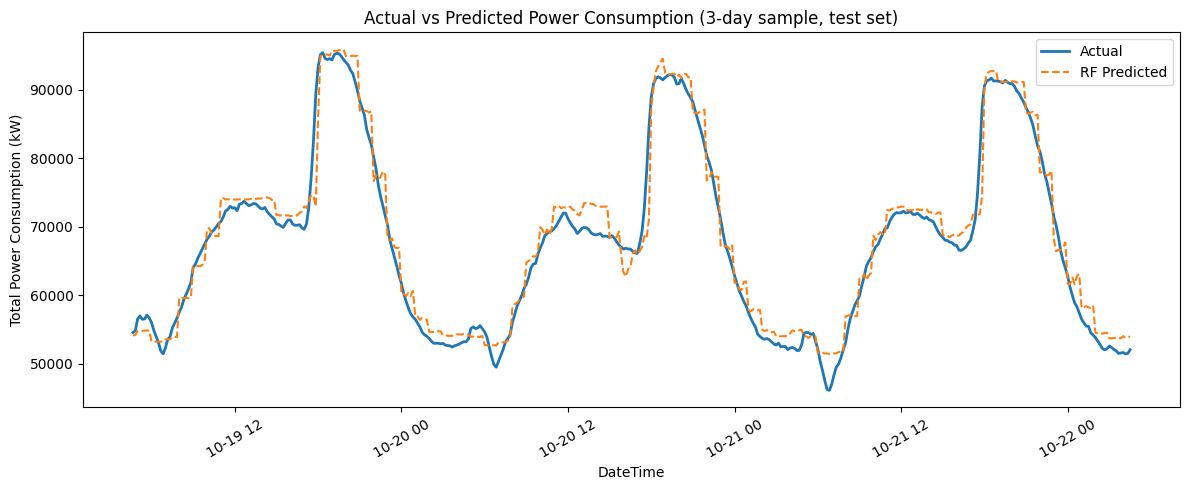

In [12]:
n_show = 24*3*6  # 3 days of 10-min readings
plt.figure(figsize=(12, 5))
plt.plot(df['DateTime'].iloc[split_idx:split_idx+n_show], y_test.iloc[:n_show], label='Actual', linewidth=2)
plt.plot(df['DateTime'].iloc[split_idx:split_idx+n_show], rfpred[:n_show], label='RF Predicted', linestyle='--')
plt.xlabel('DateTime'); plt.ylabel('Total Power Consumption (kW)')
plt.title('Actual vs Predicted Power Consumption (3-day sample, test set)')
plt.legend(); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=110)
plt.show()

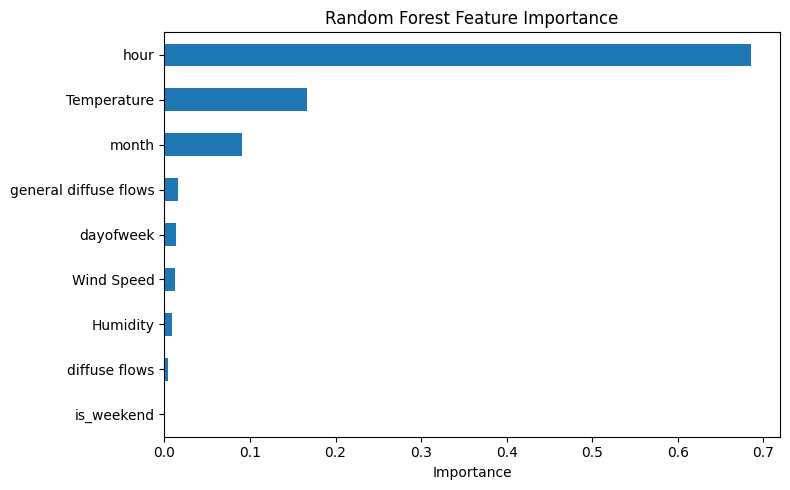

In [13]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=110)
plt.show()

## 6. Conclusion

- Hour-of-day is (unsurprisingly) the strongest predictor — demand follows a strong daily cycle.
- Random Forest cuts error roughly in half versus plain Linear Regression by capturing these non-linear time patterns.
